<a href="https://colab.research.google.com/github/rajushreya10-coder/ML_internship_tasks/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Dataset

In [55]:
ds = pd.read_csv("2_dataset.csv")

# Exploring dataset

In [56]:
print(ds.info())
print(ds.head())
print(ds.isnull().sum())
print(ds.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no    

In [57]:
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

print(f"Original shape: {ds.shape}")

for col in numerical_cols:
    # Calculate Q1, Q3, and IQR
    Q1 = ds[col].quantile(0.25)
    Q3 = ds[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds (1.5 * IQR Rule)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a boolean mask to keep non-outlier rows
    # We filter the whole DataFrame in each step, cumulative reduction
    ds = ds[(ds[col] >= lower_bound) & (ds[col] <= upper_bound)]

print(f"Shape after outlier removal: {ds.shape}")

Original shape: (545, 13)
Shape after outlier removal: (472, 13)


# Preprocessing

In [58]:
cat_col = ds.select_dtypes(include=['object']).columns.tolist()
print(cat_col)
cat_col.pop(-1)
print(cat_col)

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']


In [59]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for cols in cat_col:
    ds[cols] = le.fit_transform(ds[cols])

In [60]:
print(ds.info())

<class 'pandas.core.frame.DataFrame'>
Index: 472 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             472 non-null    int64 
 1   area              472 non-null    int64 
 2   bedrooms          472 non-null    int64 
 3   bathrooms         472 non-null    int64 
 4   stories           472 non-null    int64 
 5   mainroad          472 non-null    int64 
 6   guestroom         472 non-null    int64 
 7   basement          472 non-null    int64 
 8   hotwaterheating   472 non-null    int64 
 9   airconditioning   472 non-null    int64 
 10  parking           472 non-null    int64 
 11  prefarea          472 non-null    int64 
 12  furnishingstatus  472 non-null    object
dtypes: int64(12), object(1)
memory usage: 51.6+ KB
None


In [61]:
X = ds.iloc[:,1:].values
y = ds.iloc[:,0].values

In [62]:
print(X)

[[7420 4 2 ... 2 1 'furnished']
 [9960 3 2 ... 2 1 'semi-furnished']
 [7420 4 1 ... 2 0 'furnished']
 ...
 [3620 2 1 ... 0 0 'unfurnished']
 [2910 3 1 ... 0 0 'furnished']
 [3850 3 1 ... 0 0 'unfurnished']]


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough')
X = ct.fit_transform(X)

In [64]:
print(X)

[[1.0 0.0 0.0 ... 1 2 1]
 [0.0 1.0 0.0 ... 0 2 1]
 [1.0 0.0 0.0 ... 1 2 0]
 ...
 [0.0 0.0 1.0 ... 0 0 0]
 [1.0 0.0 0.0 ... 0 0 0]
 [0.0 0.0 1.0 ... 0 0 0]]


# Spliting dataset

In [65]:
y_transformed = np.log(y)

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_log, y_test_log = train_test_split( X, y_transformed, test_size=0.2, random_state=0)

# Feature Scaling

In [67]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, 1:2] = sc.fit_transform(X_train[:, 1:2])
X_test[:, 1:2] = sc.transform(X_test[:, 1:2])

In [68]:
print(X_train)

[[0.0 1.152024519629318 0.0 ... 1 2 0]
 [0.0 1.152024519629318 0.0 ... 0 0 0]
 [1.0 -0.868037079906742 0.0 ... 0 1 1]
 ...
 [0.0 1.152024519629318 0.0 ... 0 1 1]
 [0.0 1.152024519629318 0.0 ... 0 2 0]
 [1.0 -0.868037079906742 0.0 ... 0 0 0]]


# Model

In [69]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train_log)
y_pred_log = regressor.predict(X_test)
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test_log)

# Evaluation

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2_log = r2_score(y_test_log, y_pred_log)

print("\n Model Evaluation Results ")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2_log:.4f}")


 Model Evaluation Results 
Mean Absolute Error (MAE): 791968.40
Root Mean Squared Error (RMSE): 1050347.15
R-squared (R²): 0.6118


# Visualisation

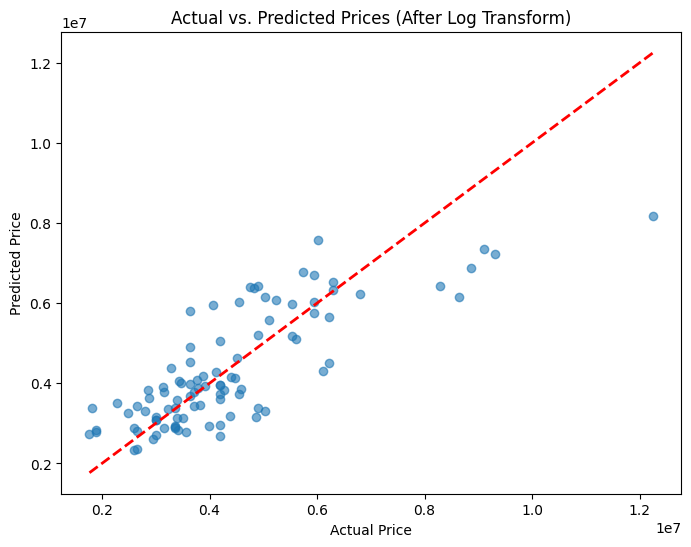

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red', linestyle='--', linewidth=2, label='Ideal Fit')
plt.title('Actual vs. Predicted Prices (After Log Transform)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()